In [14]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import *
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.plot import *
from mis_dro.experiments import ExperimentName
from mis_dro.main import get_npl_uuid, POSTERIOR_GB_COLS

In [15]:
experiment_name = ExperimentName.mmd_portfolio_synthetic
mmd_experiment_dir = Path(f"/dcs/large/u1508153/misdro/mmd_portfolio_debug/2025_01_29_{experiment_name.value}_2")
npl_samples_dir = Path(f"/dcs/large/u1508153/misdro/mmd_portfolio_debug/2025_01_29_{experiment_name.value}_samples_2")
assert mmd_experiment_dir.exists()
assert npl_samples_dir.exists()
with open(mmd_experiment_dir / "experiment.json", "r", encoding="utf-8") as json_file:
    experiment = json.load(json_file)
mmd_results_df = pd.read_csv(mmd_experiment_dir / "results.csv", index_col=["uuid", "replication"])

kl_experiment_dir = Path("/dcs/large/u1508153/misdro/debug_kl_portfolio_synthetic/kl_portfolio_synthetic_2")
assert kl_experiment_dir.exists()
kl_results_df = pd.read_csv(kl_experiment_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = pd.concat([mmd_results_df, kl_results_df])
all_results_df

solution  \
uuid                                 replication                                                      
15dfa6f4-761e-4977-8b62-f742e188977d 0            [8.085431960616617e-09, 7.48092806922679e-10, ...   
                                     1            [4.29998746646889e-09, 7.248518130236083e-10, ...   
                                     2            [2.1686742067224975e-09, 4.708491136159428e-10...   
                                     3            [1.2619257033070456e-10, 5.645111123121897e-11...   
                                     4            [1.811392037232449e-08, 8.296831217902077e-09,...   
...                                                                                             ...   
4b7ba2b1-9c95-4e54-a8bc-a6b7088d374e 95           [0.836594176648644, 0.007763250615289498, 0.00...   
                                     96           [0.9139226623360943, 0.018701093252789545, 4.8...   
                                     97           [0.7646741378435935, 7.833453264760401e-11, 0....   
                                     98           [0.8647495247063224, 6.254095093581086e-10, 0....   
                                     99           [0.8818256365870121, 7.597848546655867e-12, 7....   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
15dfa6f4-761e-4977-8b62-f742e188977d 0            0.265642         0.034181   
                                     1            0.008892         0.021246   
                                     2            0.501835         0.034658   
                                     3            0.472483         0.029908   
                                     4            0.067319         0.022672   
...                                                    ...              ...   
4b7ba2b1-9c95-4e54-a8bc-a6b7088d374e 95           0.002134         0.000547   
                                     96           0.002166         0.000560   
                                     97           0.002196         0.000553   
                                     98           0.002126         0.000531   
                                     99           0.002132         0.000535   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
15dfa6f4-761e-4977-8b62-f742e188977d 0                  0.004461  333.774210   
                                     1                  0.036334  321.422681   
                                     2                  0.297426  307.695873   
                                     3                  0.187981  306.340223   
                                     4                  0.068958  280.383610   
...                                                          ...         ...   
4b7ba2b1-9c95-4e54-a8bc-a6b7088d374e 95                 0.000238    0.213913   
                                     96                 0.000231    0.220374   
                                     97                 0.000228    0.213127   
                                     98                 0.000243    0.212637   
                                     99                 0.000213    0.176661   

                                                  setup_time  \
uuid                                 replication               
15dfa6f4-761e-4977-8b62-f742e188977d 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   
                                     3                   NaN   
                                     4                   NaN   
...                                                      ...   
4b7ba2b1-9c95-4e54-a8bc-a6b7088d374e 95                  NaN   
                                     96                  NaN   
                                     97   

In [17]:
def preprocess_results_df(results_df: pd.DataFrame, dgp: str, dataset: str = "newsvendor"):
    """Filter results, process columns, and create new columns"""
    assert len(results_df.loc[(results_df["dgp"] == dgp)]["dim"].unique()) == 1 
    num_test_observations = results_df["num_test_observations"].unique()[0]
    
    processed_df = results_df.copy()
    dim = processed_df.loc[(processed_df["dgp"] == dgp)]["dim"].unique()
    # filter by the DGP and cases where the the log partition function is feasible for epsilon
    processed_df = processed_df.loc[processed_df["dgp"] == dgp]
    if dataset != "portfolio":
        processed_df = processed_df.loc[processed_df["log_partition_constant"] < processed_df["epsilon"]]

    # get useful stats such as the number of samples and total time spent sampling
    processed_df["num_total_samples"] = processed_df["num_posterior_samples"] * processed_df["num_likelihood_samples"]
    processed_df["sample_time"] = processed_df["likelihood_time"] + processed_df["posterior_time"]

    # convert strings into list of floats where necessary
    processed_df["out_of_sample_cost"] = processed_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))
    processed_df["solution"] = processed_df["solution"].map(lambda x: convert_str_to_float_list(x, dim))

    # calculate the in-group mean and in-group variance for each replication
    processed_df["in_group_mean"] = processed_df["out_of_sample_cost"].map(np.mean)
    processed_df["in_group_var"] = processed_df["out_of_sample_cost"].map(lambda x: np.var(x, ddof=1))

    # return preprocessed dataframe
    return processed_df

def get_agg_df(results_df: pd.DataFrame, gb_cols: list[str]):
    """Groupby the given columns then apply summary statistics for each group"""
    # assert len(results_df["num_replications"].unique()) == 1
    # assert len(results_df["num_test_observations"].unique()) == 1
    num_replications = results_df["num_replications"].unique()[0]
    num_test_observations = results_df["num_test_observations"].unique()[0]
    gb = results_df.groupby(by=gb_cols)
    agg_df = gb.agg(
        out_of_sample_mean = pd.NamedAgg(column="out_of_sample_cost", aggfunc=lambda x: np.mean(np.concatenate(x.values))),
        out_of_sample_var = pd.NamedAgg(column="out_of_sample_cost", aggfunc=lambda x: np.var(np.concatenate(x.values), ddof=1)),
        sum_of_in_group_var = pd.NamedAgg(column="in_group_var", aggfunc=lambda x: float(num_test_observations - 1) / float(num_replications * num_test_observations - 1) * np.sum(x.values)),
        var_of_in_group_mean = pd.NamedAgg(column="in_group_mean", aggfunc=lambda x: float(num_test_observations * (num_replications - 1)) / float(num_replications * num_test_observations - 1) * np.var(x, ddof=1)),
        mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
        std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
        mean_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.mean),
        std_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.std),
    )
    return agg_df

In [18]:
# NOTE filter by DGP
filter_dgp = "portfolio_contaminated_multivariate_normal"
dataset = "portfolio_synthetic"
# assert filter_dgp in all_results_df["dgp"] and dataset in all_results_df["dataset"]
results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)
agg_df = get_agg_df(results_df, ["algorithm", "contamination", "epsilon", "inference"])
agg_df

/tmp/dcs-tmp.u1508153/ipykernel_400427/2712397841.py:35: FutureWarning: The provided callable <function mean at 0x7f9264165b20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/tmp/dcs-tmp.u1508153/ipykernel_400427/2712397841.py:35: FutureWarning: The provided callable <function std at 0x7f9264165c60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm   contamination epsilon inference                       
dro_bas_mmd 0.0           0.0001  npl_mmd              3.337245   
                          0.0010  npl_mmd              3.337245   
                          0.0100  npl_mmd              3.240562   
                          0.1000  npl_mmd              2.941703   
                          1.0000  npl_mmd              0.820487   
...                                                         ...   
kl_pp       0.2           1.0000  bayes                2.541212   
                          1.5000  bayes                2.535754   
                          2.0000  bayes                2.532018   
                          2.5000  bayes                2.529150   
                          3.0000  bayes                2.525177   

                                             out_of_sample_var  \
algorithm   contamination epsilon inference                      
dro_bas_mmd 0.0           0.0001  npl_mmd            31.478406   
                          0.0010  npl_mmd            31.478406   
                          0.0100  npl_mmd            29.232449   
                          0.1000  npl_mmd            13.595316   
                          1.0000  npl_mmd             3.658974   
...                                                        ...   
kl_pp       0.2           1.0000  bayes               4.096946   
                          1.5000  bayes               4.118228   
                          2.0000  bayes               4.133811   
                          2.5000  bayes               4.147402   
                          3.0000  bayes               4.162537   

                                             sum_of_in_group_var  \
algorithm   contamination epsilon inference                        
dro_bas_mmd 0.0           0.0001  npl_mmd              30.872992   
                          0.0010  npl_mmd              30.872992   
                          0.0100  npl_mmd              28.748029   
                          0.1000  npl_mmd              13.404776   
                          1.0000  npl_mmd               3.595824   
...                                                          ...   
kl_pp       0.2           1.0000  bayes                40.561985   
                          1.5000  bayes                40.761895   
                          2.0000  bayes                40.906811   
                          2.5000  bayes                41.035580   
                          3.0000  bayes                41.175242   

                                             var_of_in_group_mean  \
algorithm   contamination epsilon inference                         
dro_bas_mmd 0.0           0.0001  npl_mmd                0.605414   
                          0.0010  npl_mmd                0.605414   
                          0.0100  npl_mmd                0.484420   
                          0.1000  npl_mmd                0.190540   
                          1.0000  npl_mmd                0.063149   
...                                                           ...   
kl_pp       0.2           1.0000  bayes                  0.040399   
                          1.5000  bayes                  0.041589   
                          2.0000  bayes                  0.042595   
                          2.5000  bayes                  0.043255   
                          3.0000  bayes                  0.044330   

                                             mean_solve_time  std_solve_time  \
algorithm   contamination epsilon inference                                    
dro_bas_mmd 0.0           0.0001  npl_mmd         299.729992       24.117828   
                          0.0010  npl_mmd         288.489128       21.223125   
                          0.0100  npl_mmd         283.972354       23.342242   
                          0.1000  npl_mmd         283.024025       20.354493   
                          1.0000  npl_mmd         2

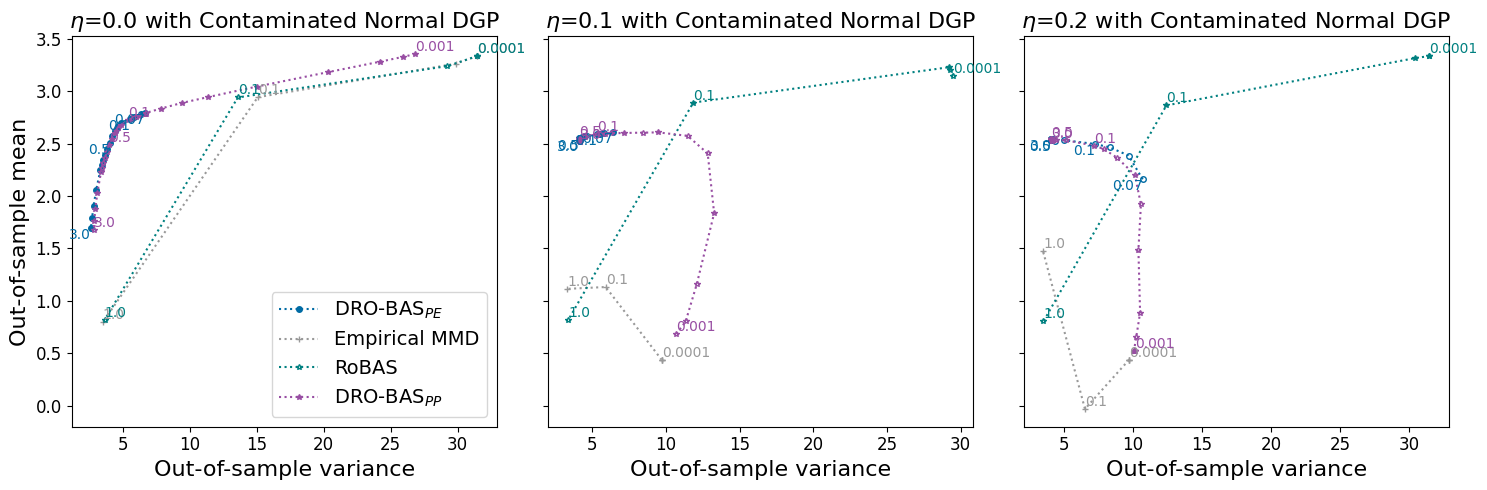

In [19]:
contamination_list = agg_df.index.get_level_values("contamination").unique().tolist()
nrows = 1
ncols = len(contamination_list)
trim_epsilon = 1.0
total_samples = 100
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, nrows*5), sharey=True)
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
    
for j, contamination in enumerate(contamination_list):
    axis_df = agg_df.loc[:, contamination, :, :] #
    axis_df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
    for (algorithm, inference) in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
        df = axis_df.loc[algorithm, :, inference]
        # for k in range(j, len(contamination_list)):
        alpha = 1.0
        is_labelled=True
            # if j != k:
            #     alpha = 0.2
            #     is_labelled = False
        mean_variance_plot(axes[j], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)

    if j == 0:
        axes[j].legend(fontsize=14)
        axes[j].set_ylabel("Out-of-sample mean", fontsize=16)
        
    axes[j].set_title("$\eta$" + f"={contamination} with {NiceNameDGP[filter_dgp]}", fontsize=16)
    axes[j].set_xlabel("Out-of-sample variance", fontsize=16)
    axes[j].tick_params(axis='both', which='major', labelsize=12)

# for j in range(ncols):  # Start from the second column
#     axes[j].tick_params(left=False, labelleft=False)  # Turn off ticks and labels

# Ensure the first column retains its ticks and labels
# axes[0].tick_params(left=True, labelleft=True, labelsize=12)  # Explicitly enable ticks and labels

plt.tight_layout()
plt.show()

In [7]:
idx = 10
dgp = experiment[idx]["dgp"]
num_observations = experiment[idx]["num_observations"]
contamination = experiment[idx]["contamination"]
dim = experiment[idx]["dim"]
replication = 0
generator = np.random.default_rng(replication)
data = sample_dgp(
    dgp, num_observations, dim=dim, contamination=contamination, generator=generator
)
dgp_mean = np.array([0.0, 1.5, -1.0, -3.0, 3.5])
dgp_mean_outl = dgp_mean + np.array([0.0, 50.0, 50.0, 50.0, 0.0])
dgp_cov = np.diag(np.array([1.0, 1.0, 1.0, 2.0, 3.0]))
print(json.dumps(experiment[idx], indent=4))

{
    "algorithm": "dro_bas_mmd",
    "contamination": 0.2,
    "dataset": "portfolio_synthetic",
    "dgp": "portfolio_contaminated_multivariate_normal",
    "dim": 5,
    "epsilon": 0.0001,
    "eta": 0.1,
    "inference": "npl_mmd",
    "lengthscale": -1.0,
    "likelihood": "multivariate_normal",
    "normalise": false,
    "num_certify_points": 200,
    "num_likelihood_samples": 10,
    "num_observations": 100,
    "num_posterior_samples": 90,
    "num_replications": 10,
    "num_test_observations": 12,
    "posterior": "npl",
    "uuid": "6f3ae47c-9f56-489f-8a2d-ff0c8210fd7d"
}


In [8]:
# train a bayesian model with normal likelihood and NIW posterior
bayes_posterior = "normal_inverse_wishart"
theta_prior = default_prior_params(bayes_posterior, dim=dim)
theta_posterior = get_posterior_params(bayes_posterior, data, theta_prior)
mu_post, _, iota_post, Psi_post = theta_posterior
expected_Sigma = Psi_post / (iota_post - Psi_post.shape[0] - 1)

In [9]:
# load one NPL posterior sample
posterior_df = pd.read_csv(npl_samples_dir / "npl_settings.csv").set_index(POSTERIOR_GB_COLS)
npl_params = {key: experiment[idx][key] for key in POSTERIOR_GB_COLS}
npl_uuid = get_npl_uuid(posterior_df, npl_params)
npl_uuid_dir = npl_samples_dir / npl_uuid
path_to_csv = npl_uuid_dir / f"npl_sample_{replication}.csv"
theta_sample = pd.read_csv(path_to_csv, index_col=False, header=None).values
i = 0
npl_mu = theta_sample[i,:dim]
vec_cov = theta_sample[i,dim:]
npl_cov = cholesky_param_to_covariance(dim, vec_cov)
npl_cov

array([[ 0.01381498, -0.02463907,  0.2766779 , -0.12411889, -0.01283187],
       [-0.02463907,  0.10103967, -0.2593299 ,  0.92120046,  0.05967113],
       [ 0.2766779 , -0.2593299 ,  6.51121561,  0.44304377, -0.26583293],
       [-0.12411889,  0.92120046,  0.44304377, 10.05949088, -0.04435869],
       [-0.01283187,  0.05967113, -0.26583293, -0.04435869,  8.65246922]])

Text(0.5, 1.0, 'Bayes posterior')

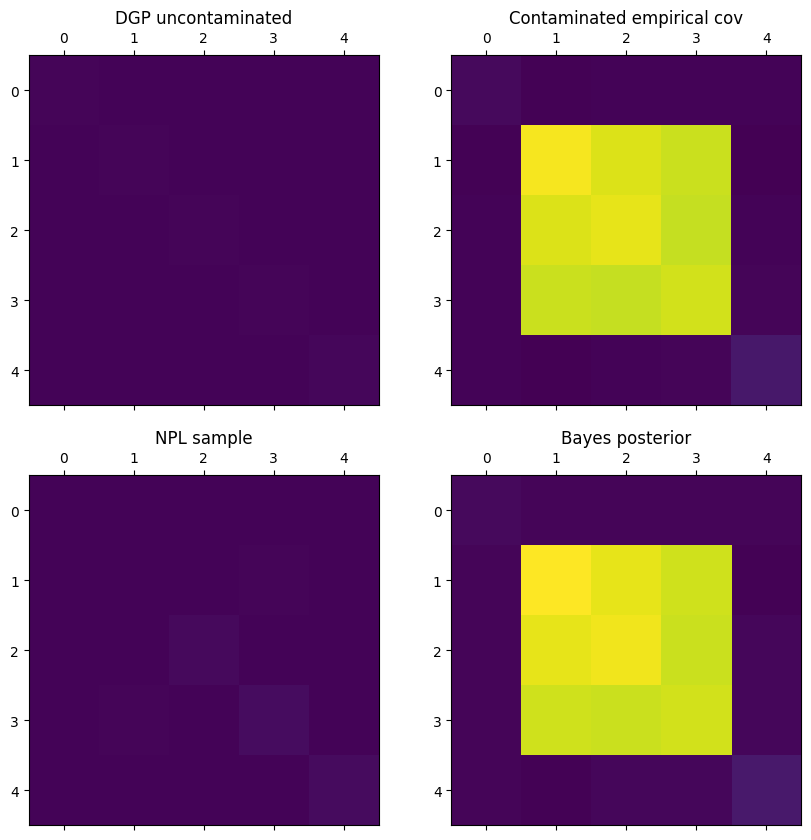

In [10]:
# plot the posterior against the DGP
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
all_covs = np.concatenate([dgp_cov, expected_Sigma, np.cov(data.T), npl_cov])
vmax = np.max(all_covs)
vmin = np.min(all_covs)

axes[0][0].matshow(dgp_cov, vmin=vmin, vmax=vmax)
axes[0][0].set_title("DGP uncontaminated")

axes[0][1].matshow(np.cov(data.T), vmin=vmin, vmax=vmax)
axes[0][1].set_title("Contaminated empirical cov")

axes[1][0].matshow(npl_cov, vmin=vmin, vmax=vmax)
axes[1][0].set_title("NPL sample")

axes[1][1].matshow(expected_Sigma, vmin=vmin, vmax=vmax)
axes[1][1].set_title("Bayes posterior")

Text(0.5, 1.0, 'NPL sample')

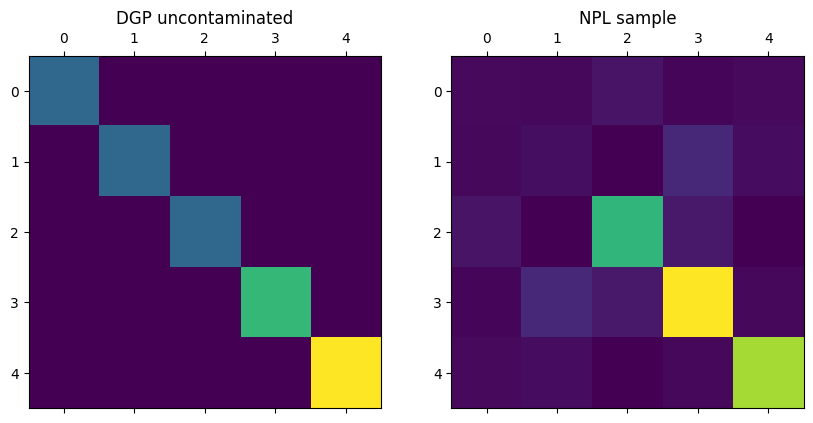

In [11]:
# plot the posterior against the DGP
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
all_covs = np.concatenate([dgp_cov, npl_cov])
vmax = np.max(all_covs)
vmin = np.min(all_covs)

axes[0].matshow(dgp_cov)
axes[0].set_title("DGP uncontaminated")

axes[1].matshow(npl_cov)
axes[1].set_title("NPL sample")
